<a href="https://colab.research.google.com/github/onyxs-prog/AI-ML-projects/blob/main/module_2_mini_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Building an XGBoost Model for Airline Passenger Satisfaction Prediction

## Overview
This project focuses on using machine learning techniques to predict airline passenger satisfaction. By leveraging the XGBoost algorithm, we aim to build a robust model that can accurately classify passengers as satisfied or dissatisfied based on various features such as flight distance, seat comfort, and service quality.

## Objective
Develop a machine learning model using XGBoost to predict passenger satisfaction. The project will cover the complete machine learning pipeline, including data preprocessing, feature engineering, model training, hyperparameter tuning, and evaluation.

## Learning Outcomes
1. Understand the importance of data preprocessing and feature engineering in machine learning.
2. Learn to implement and tune the XGBoost algorithm for classification tasks.
3. Gain experience in evaluating model performance using metrics such as accuracy, precision, recall, and F1 score.
4. Explore feature importance and interpret model results.
5. Compare the performance of XGBoost with other models like Decision Trees and Random Forests.

---

## Step 1: Define the Problem
### Task:
Understand the problem and its real-world implications. Predicting passenger satisfaction can help airlines improve customer experience, optimize services, and increase customer loyalty.

### Mini-task:
Write a brief paragraph on how predicting passenger satisfaction can benefit the airline industry.

---


**Benefit of predicting customers satisfaction in the airline industry**

The airline industry is a competitive industry and at such, passenger satisfaction is one of the major factor to consider in other to stand out in the airline industry. When a passenger is dissatisfied the passenger is most likely to check out or book another airline during his/her next travel. At such, airline companies must prioritze customer satisifaction. customers dissatifaction often led to bad making or leaving bad review at review site, social media and other public places thus afecting the the image of the company and other and at such leading to lost of revenue and customers. The following are the benefit of customers satisfaction in the airline industry.

*   Increase in customer referal : this lead to more customers and more business
*   inrease in the company revenue

*   Increase in customers loyalty
*   increase in the airline reputation.


When the passenger satisfaction is low the above will be the reverse.







## Step 2: Data Collection
### Task:
Collect a dataset suitable for predicting passenger satisfaction. The dataset used in this project is the `Invistico_Airline.csv`, which contains various features related to passenger experiences.

### Mini-task:
Load the dataset and inspect the first few rows to understand its structure.

#### Hint:
Use the `pandas` library to load the dataset and display the first 10 rows.

```python
import pandas as pd

# Load the dataset
airline_data = pd.read_csv('..\sample_data\Invistico_Airline.csv')

# Display the first 10 rows
### YOUR CODE HERE ###
```

---


In [ ]:
# Import Data Files from Google Drive

import requests
import pandas as pd
from io import StringIO
def read_gd(sharingurl):
    file_id = sharingurl.split('/')[-2]
    download_url='https://drive.google.com/uc?export=download&id=' + file_id
    url = requests.get(download_url).text
    csv_raw = StringIO(url)
    return csv_raw

url = "https://drive.google.com/file/d/1gG0NpYi2hUh8oaYJg7tIsb157D0Qgpzt/view?usp=sharing"
gdd = read_gd(url)

df = pd.read_csv(gdd)

df.head(10)

,satisfaction,Customer Type,Age,Type of Travel,Class,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,Gate location,...,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
0,satisfied,Loyal Customer,65,Personal Travel,Eco,265,0,0,0,2,...,2,3,3,0,3,5,3,2,0,0.0
1,satisfied,Loyal Customer,47,Personal Travel,Business,2464,0,0,0,3,...,2,3,4,4,4,2,3,2,310,305.0
2,satisfied,Loyal Customer,15,Personal Travel,Eco,2138,0,0,0,3,...,2,2,3,3,4,4,4,2,0,0.0
3,satisfied,Loyal Customer,60,Personal Travel,Eco,623,0,0,0,3,...,3,1,1,0,1,4,1,3,0,0.0
4,satisfied,Loyal Customer,70,Personal Travel,Eco,354,0,0,0,3,...,4,2,2,0,2,4,2,5,0,0.0
5,satisfied,Loyal Customer,30,Personal Travel,Eco,1894,0,0,0,3,...,2,2,5,4,5,5,4,2,0,0.0
6,satisfied,Loyal Customer,66,Personal Travel,Eco,227,0,0,0,3,...,5,5,5,0,5,5,5,3,17,15.0
7,satisfied,Loyal Customer,10,Personal Travel,Eco,1812,0,0,0,3,...,2,2,3,3,4,5,4,2,0,0.0
8,satisfied,Loyal Customer,56,Personal Travel,Business,73,0,0,0,3,...,5,4,4,0,1,5,4,4,0,0.0
9,satisfied,Loyal Customer,22,Personal Travel,Eco,1556,0,0,0,3,...,2,2,2,4,5,3,4,2,30,26.0










## Step 3: Exploratory Data Analysis (EDA)
### Task:
Analyze the dataset to understand the distribution of features, identify missing values, and explore relationships between variables.

### Mini-task:
Visualize the distribution of the target variable (satisfaction) and inspect the data types of each column.

#### Hint:
Use `value_counts()` to check the distribution of the target variable and `dtypes` to inspect the data types.

```python
import matplotlib.pyplot as plt

# Visualize the distribution of the target variable
### YOUR CODE HERE ###

# Display data types
### YOUR CODE HERE ###
```

---


,0
satisfaction,object
Customer Type,object
Age,int64
Type of Travel,object
Class,object
Flight Distance,int64
Seat comfort,int64
Departure/Arrival time convenient,int64
Food and drink,int64
Gate location,int64


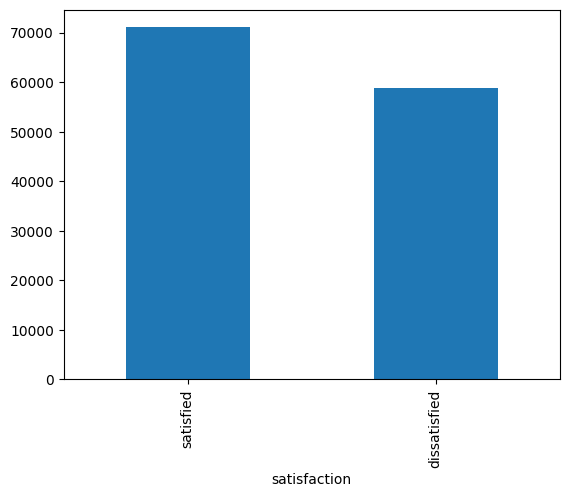

In [ ]:
import matplotlib.pyplot as plt

# Visualize the distribution of the target variable
### YOUR CODE HERE ###
df['satisfaction'].value_counts().plot(kind='bar')

#display the datatypes
df.dtypes


## Step 4: Data Preprocessing
### Task:
Preprocess the data to prepare it for modeling. This includes handling missing values, encoding categorical variables, and splitting the data into training and testing sets.

### Mini-task:
Convert categorical variables into numerical format using one-hot encoding and split the data into training and testing sets.

#### Hint:
Use `pd.get_dummies()` to encode categorical variables and `train_test_split()` to split the data.

```python
from sklearn.model_selection import train_test_split

# Convert categorical variables to numerical using one-hot encoding
### YOUR CODE HERE ###

# Define the target variable and features
### YOUR CODE HERE ###

# Split the data into training and testing sets
### YOUR CODE HERE ###
```

---


In [ ]:
from sklearn.model_selection import train_test_split

#convert categorical variable to numerical using one-hot encoding
encoded_df  = pd.get_dummies(df, columns=['satisfaction','Customer Type', 'Type of Travel','Class']  )

#droping the columns which is the target variable
X = encoded_df.drop(['satisfaction_satisfied', 'satisfaction_dissatisfied'], axis=1)
y = encoded_df['satisfaction_satisfied']

#Now I want to split the data for my model training
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

## Step 5: Model Training Using XGBoost
### Task:
Train an XGBoost model on the preprocessed data. Perform hyperparameter tuning using GridSearchCV to find the optimal parameters.

### Mini-task:
Define the XGBoost classifier and perform hyperparameter tuning.

#### Hint:
Use `XGBClassifier()` and `GridSearchCV()` to tune hyperparameters like `max_depth`, `learning_rate`, and `n_estimators`.

```python
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

# Define the XGBoost classifier
### YOUR CODE HERE ###

# Define the parameters for hyperparameter tuning
### YOUR CODE HERE ###

# Perform GridSearchCV
### YOUR CODE HERE ###

# Display the best parameters
### YOUR CODE HERE ###
```

---

In [ ]:
!pip install xgboost

In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV



xgbmodel = XGBClassifier(eval_metric='logloss')

params = {
    'max_depth': [2,3,5],
    'learning_rate': [0.01,0.1,0.2],
    'n_estimators':[100,200]

}

gridsearch = GridSearchCV(estimator=xgbmodel, param_grid=params, cv=5)

gridsearch.fit(X_train, y_train)

print(gridsearch.best_params_)





{'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 200}


In [ ]:
model = XGBClassifier(eval_metric='logloss', max_depth=5, learning_rate=0.2, n_estimators=200)
model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.2, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)


## Step 6: Model Evaluation
### Task:
Evaluate the model's performance using metrics such as accuracy, precision, recall, and F1 score. Visualize the results using a confusion matrix and feature importance plot.

### Mini-task:
Evaluate the model on the test set and visualize the confusion matrix and feature importance.

#### Hint:
Use `accuracy_score()`, `precision_score()`, `recall_score()`, and `f1_score()` to evaluate the model. Use `confusion_matrix()` and `plot_importance()` for visualization.

```python
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

# Predict on the test set
### YOUR CODE HERE ###

# Calculate evaluation metrics
### YOUR CODE HERE ###

# Plot the confusion matrix
### YOUR CODE HERE ###

# Plot feature importance
### YOUR CODE HERE ###
```

---

Accuracy: 0.9569
Precision: 0.9685
Recall: 0.9527
F1 Score: 0.9606


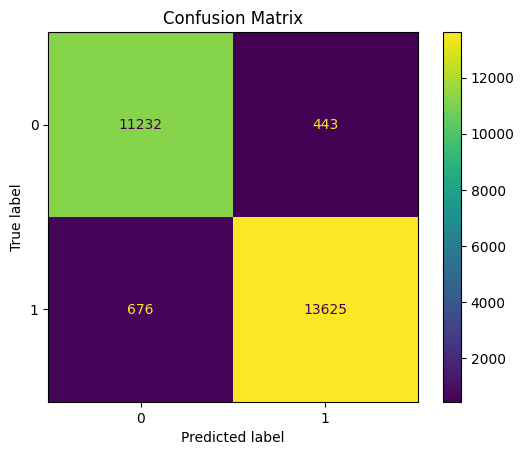

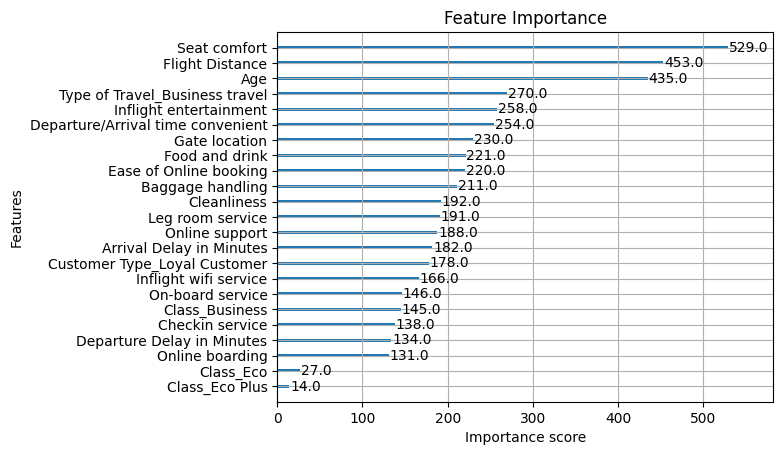

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predict on the test set
y_pred = model.predict(X_test)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

# Plot the confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title('Confusion Matrix')
plt.show()

# Plot feature importance
from xgboost import plot_importance
plot_importance(model)
plt.title('Feature Importance')
plt.show()


## Step 7: Model Comparison (Optional)
### Task:
Compare the performance of the XGBoost model with other models like Decision Trees and Random Forests.

### Mini-task:
Train a Decision Tree and Random Forest model, and compare their performance with the XGBoost model.

#### Hint:
Use `DecisionTreeClassifier()` and `RandomForestClassifier()` to train the models and compare their accuracy.

```python
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Train a Decision Tree model
### YOUR CODE HERE ###

# Train a Random Forest model
### YOUR CODE HERE ###

# Compare model performance
### YOUR CODE HERE ###
```

---

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

#I am trying the model to compare with here
dtmodel = DecisionTreeClassifier()
rfmodel = RandomForestClassifier()

dtmodel.fit(X_train, y_train)
rfmodel.fit(X_train, y_train)

y_pred_dt = dtmodel.predict(X_test)
y_pred_rf = rfmodel.predict(X_test)

accuracy_dt = accuracy_score(y_test, y_pred_dt)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Decision Tree Accuracy: {accuracy_dt:.4f}")
print(f"Random Forest Accuracy: {accuracy_rf:.4f}")





Decision Tree Accuracy: 0.9363
Random Forest Accuracy: 0.9581


## Considerations
**What are some key takeaways you learned from this project?**
- Reflect on the importance of hyperparameter tuning and feature engineering.
- Consider how the model's insights can be applied to improve airline services.

**How would you share your findings with a team?**
- Prepare a presentation with visualizations and key metrics.
- Discuss the impact of different features on passenger satisfaction.

**What would you share with and recommend to stakeholders?**
- Highlight the key features that contribute most to passenger satisfaction.
- Recommend strategies to improve services based on the model's insights.

## Considerations

**What are some key takeaways I learned from this project?**

*   **Importance of Data Preprocessing:** I learned that handling categorical variables through one-hot encoding was crucial to prepare the data for the XGBoost model.
*   **Power of XGBoost:** I saw that the XGBoost algorithm demonstrated high accuracy in predicting passenger satisfaction.
*   **Hyperparameter Tuning:** Using GridSearchCV helped me find optimal parameters (`max_depth`, `learning_rate`, `n_estimators`) to improve model performance.
*   **Feature Importance:** Analyzing feature importance provided me with valuable insights into which factors (like Seat comfort, Flight Distance, Age, etc.) are most influential in determining passenger satisfaction.

**How would I share my findings with a team?**

*   **Presentation:** I would prepare a presentation summarizing the project objective, methodology (data preprocessing, model training, tuning), key results (accuracy, precision, recall, F1-score), and insights from feature importance.
*   **Visualizations:** I would include the confusion matrix to show the model's performance in classifying satisfied vs. dissatisfied passengers, and the feature importance plot to highlight the most impactful features.
*   **Code Walkthrough:** I would share the notebook and walk the team through the code, explaining each step of the process.
*   **Discussion:** I would facilitate a discussion on the implications of the findings and potential next steps.

**What would I share with and recommend to stakeholders?**

*   **Key Findings:** I would present the overall accuracy and performance metrics of the model, emphasizing its ability to predict passenger satisfaction with high confidence.
*   **Top Influencing Factors:** I would highlight the features that the model identified as most important for satisfaction (e.g., Seat comfort, Inflight wifi service, Flight Distance).
*   **Actionable Recommendations:** Based on the influential features, I would recommend strategies for improving passenger satisfaction. For example, if "Seat comfort" is a top feature, I would recommend investing in more comfortable seating options. If "Inflight wifi service" is important, I would suggest improving the quality and reliability of the wifi.
*   **Potential Business Impact:** I would explain how improving these key areas can lead to increased customer loyalty, positive reviews, and ultimately, revenue growth.
*   **Future Steps:** I would suggest further analysis or model improvements, such as exploring other features, collecting more data, or deploying the model for real-time predictions.